# 02 - Topic Analysis of Clothing Reviews with Embeddings
The four deliverables from the brief, end to end, using the project's `src` modules (one shared encoder everywhere, no API keys):

1. **Create the embeddings** -> `embeddings`
2. **Dimensionality reduction & visualization** -> `embeddings_2d` + a 2D plot
3. **Feedback categorization** -> assign each review a theme (`feedback_categories`)
4. **Similarity search** -> `find_similar_reviews(...)`, applied to the first review -> `most_similar_reviews`

> **Honesty boundary.** The themes have no ground-truth labels, so theme assignment is an *unsupervised triage aid*, not a scored classifier. The measurable claims live in the final section, where a linear probe tests the embedding space against the labels we *do* have.

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, json
from pathlib import Path
from src.data import load_reviews
from src.embeddings import embed_cached
df = load_reviews(); review_texts = df['Review Text'].tolist()
print(f'{len(review_texts):,} reviews')

22,634 reviews


## 1. Create and store the embeddings
`all-MiniLM-L6-v2` (384-dim, L2-normalized). Cached on disk, so this is instant after the first run.

In [2]:
embeddings = embed_cached(review_texts, Path('../artifacts/embeddings/review_embeddings.npy'))
print('embeddings:', embeddings.shape, embeddings.dtype)

embeddings: (22634, 384) float32


## 2. Dimensionality reduction & visualization
t-SNE down to 2 dimensions. t-SNE is slow on 22k points, so we project a random sample for the picture - the cluster structure is already clear. `embeddings_2d` is the 2D array of that sample.

In [3]:
from src.reduce import apply_tsne
from src.themes import build_theme_matrix, assign_themes
embeddings_2d, sample_idx = apply_tsne(embeddings, sample_size=3000)
print('embeddings_2d:', embeddings_2d.shape)

embeddings_2d: (3000, 2)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

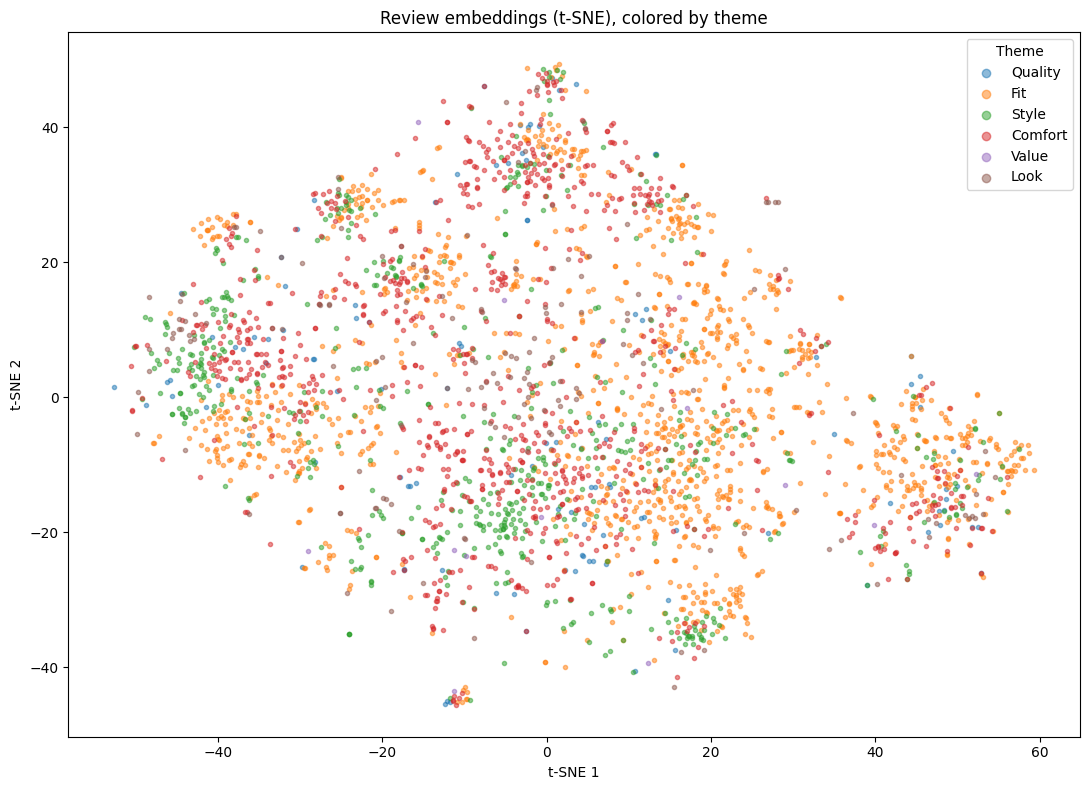

In [4]:
names, anchors, owners = build_theme_matrix()
all_themes = np.array(assign_themes(embeddings, anchors, owners, names))
sample_themes = all_themes[sample_idx]
plt.figure(figsize=(11,8))
for t in names:
    m = sample_themes == t
    plt.scatter(embeddings_2d[m,0], embeddings_2d[m,1], s=9, alpha=0.5, label=t)
plt.legend(title='Theme', markerscale=2); plt.title('Review embeddings (t-SNE), colored by theme')
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2'); plt.tight_layout(); plt.show()

## 3. Feedback categorization
Identify which reviews discuss **quality, fit, style, comfort, value, look**. Each theme is described by a few anchor phrases; a review is assigned to the theme whose best-matching anchor is closest (cosine).

*(The reference snippet selects with `min(..., key=lambda x: x['index'])`, which always returns the first theme; the correct choice is the nearest anchor.)*

In [5]:
feedback_categories = list(all_themes)
pd.Series(feedback_categories).value_counts()

Fit        9382
Comfort    6672
Style      4404
Look       1213
Quality     844
Value       119
Name: count, dtype: int64

Two example reviews per theme - a quick eyeball that the triage is on-topic:

In [6]:
labels, scores = assign_themes(embeddings, anchors, owners, names, return_scores=True)
labels = np.array(labels)
for t in names:
    idx = np.where(labels == t)[0]
    top = idx[np.argsort(-scores[idx])[:2]]
    print(f'\n### {t}')
    for i in top: print('  -', review_texts[i][:110])


### Quality
  - Poor quality. i expected much more from the material.
  - Well made & lined. great find for the fall!

### Fit
  - Runs very large. ordered a smaller size due to other reviews but should have ordered several sizes smaller
  - ... runs large which is the opposite of what i see in the majority of others' reviews. since most reviews say 

### Style
  - Extremely flattering. an easy dress to wear - good choice for both day and evening
  - Flattering, flirty, bright, beautiful romper. i wish it come in other colors because i want more!!!!

### Comfort
  - Very nice soft fabric, has a nice swingy drape and flair. i use it to work out in , sleep in and just hang out
  - I returned this item. it was soft. very blah fabric. nothing special.

### Value
  - There is no way this is worth the price. i was deeply disappointed when it arrived. the material is thin and f
  - Love it. got a lot of compliments with it.
buy it, it's worth it especially with the sale price right now.

###

## 4. Similarity search
`find_similar_reviews` queries a Chroma index built from the *same* embeddings and returns the closest reviews - the basis for a faster, more consistent customer-service reply. Applied to the first review, as the brief asks.

In [7]:
from src.rag import find_similar_reviews
example_review = review_texts[0]
hits = find_similar_reviews(example_review, n=3)
most_similar_reviews = [h['review'] for h in hits]
most_similar_reviews

['Absolutely wonderful - silky and sexy and comfortable',
 'Very comfortable, flattering, washes nicely- love it!',
 'Wonderful and comfortable dress, very sweet.']

In [8]:
# with metadata, the way a support tool would surface them
for h in hits:
    print(f"[{h['distance']:.3f}] ({h['department']}, {h['rating']} stars) {h['review'][:90]}")

[-0.000] (Intimate, 4 stars) Absolutely wonderful - silky and sexy and comfortable
[0.269] (Tops, 4 stars) Very comfortable, flattering, washes nicely- love it!
[0.285] (Dresses, 5 stars) Wonderful and comfortable dress, very sweet.


## Is the embedding space actually meaningful?
The themes above are unlabeled, so instead of a fake 'theme accuracy' we test whether the embeddings encode the labels we *do* have. A linear probe on frozen embeddings vs. a TF-IDF bag-of-words baseline (same classifier, same split), plus a retrieval proxy. Numbers loaded from `artifacts/metrics_summary.json` (`python -m src.evaluate`).

In [9]:
m = json.load(open('../artifacts/metrics_summary.json'))
rows = []
for name, p in m['linear_probe'].items():
    rows.append([name, 'TF-IDF baseline', round(p['tfidf_baseline']['accuracy'],3), round(p['tfidf_baseline']['weighted_f1'],3)])
    rows.append([name, 'Embeddings',      round(p['embeddings']['accuracy'],3),     round(p['embeddings']['weighted_f1'],3)])
display(pd.DataFrame(rows, columns=['label','features','accuracy','weighted_f1']))
pr = m['retrieval_proxy']
print(f"retrieval precision@{pr['k']}: {pr['precision@3']:.3f}  vs random {pr['random_baseline']:.3f}  ({pr['lift_x']}x)")

,label,features,accuracy,weighted_f1
0,recommended,TF-IDF baseline,0.891,0.880
1,recommended,Embeddings,0.863,0.850
2,department,TF-IDF baseline,0.839,0.821
3,department,Embeddings,0.850,0.840


retrieval precision@3: 0.797  vs random 0.304  (2.62x)


**Read it honestly.**
- On **department** (a semantic label) the embeddings edge out TF-IDF, and on **retrieval** they crush chance (~2.6x) - semantics is where they win.
- On **binary sentiment**, TF-IDF actually wins: these reviews are short and sentiment-laden, the home turf of bag-of-words. Embeddings don't beat everything, and saying so is the point.
- The themes remain a useful triage lens for routing feedback - just not a measured classifier.